# Jurnal Modul 3 #

# Import Library # 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Membaca dan menampilkan citra #

(450, 800, 3)


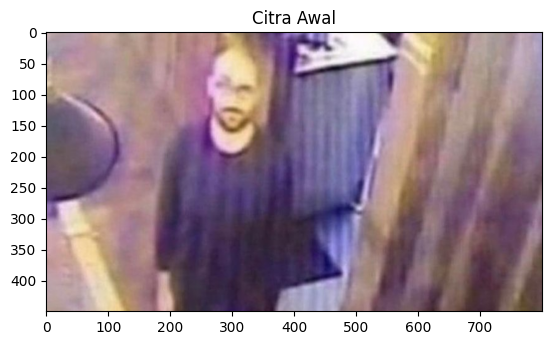

In [7]:
Objek1 = cv2.imread('backup.jpg')
GambarGray = cv2.cvtColor(Objek1, cv2.COLOR_BGR2GRAY)

gambarRGB = cv2.cvtColor(Objek1, cv2.COLOR_BGR2RGB)
print(gambarRGB.shape)
plt.title("Citra Awal")
plt.imshow(gambarRGB, cmap='gray')

# Membaca dan menampilkan citra grayscale #

(450, 800)


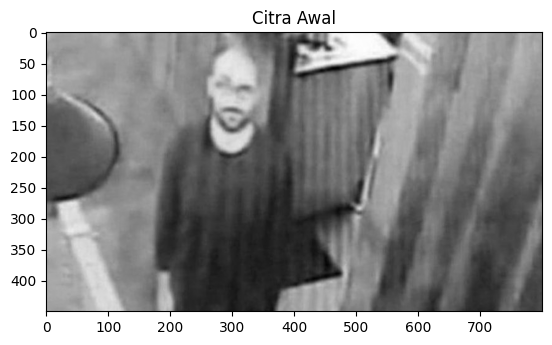

In [9]:
gray1 = Objek1
print(gray1.shape)
plt.title("Citra Awal")
plt.imshow(gray1, cmap='gray')

# Implementasi Konvolusi #

In [18]:
def convolution(gray1, kernel):

    size = kernel.shape[0]

    pad_size = size // 2

    padded = np.pad(gray1, pad_size, mode='constant')

    canvas = np.zeros_like(gray1).astype(np.float32)

    height, width = gray1.shape

    for i in range(height):

        for j in range(width):
        
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

# Kernel Smoothing dan Sharpening #

In [19]:
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

# CCTV : Smoothing, Sharpening dan Kombinasi #

Smoothing digunakan untuk menghaluskan citra dan mengurangi noise tapi menyebabkan gambar blur.
Sedangkan, Sharpening digunakan untuk memperjelas detail dan tepi citra tapi memperkuat noise.
Jadi gabungan Smoothing + Sharpening digunakan agar citra jadi lebih seimbang karena noisenya dikurangi dulu sebelum detail nya dipertegas.

Perbedaan antara mean, median, dan modus, adalah mean menghasilkan citra yang halus tetapi cenderung blur, median mengurangi noise tetapi menjaga tepi, sedangkan modus mempertahankan nilai piksel yang paling sering muncul sehingga hasilnya lebih stabil namun tidak sehalus mean.


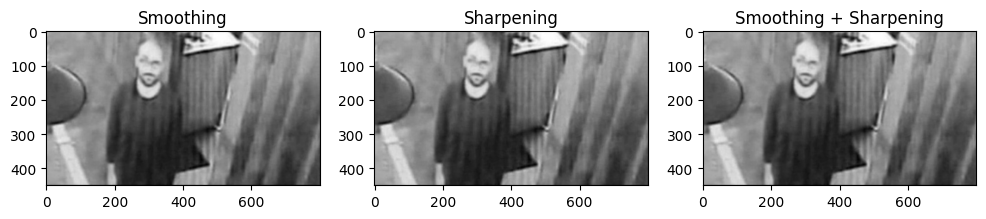

In [24]:
hasil_smoothing = convolution(gray1, kernelSmoothing)
hasil_sharpening = convolution(gray1, kernelSharpening)

Smoothing_Sharpening = convolution(gray1, kernelSmoothing)
Smoothing_Sharpening1 = convolution(Smoothing_Sharpening, kernelSharpening)

plt.figure(figsize=(12,7))

plt.subplot(2,3,1)
plt.imshow(hasil_smoothing, cmap='gray')
plt.title('Smoothing')

plt.subplot(2,3,2)
plt.imshow(hasil_sharpening, cmap='gray')
plt.title('Sharpening')

plt.subplot(2,3,3)
plt.imshow(Smoothing_Sharpening, cmap='gray')
plt.title('Smoothing + Sharpening')

plt.show()

# Kernel Sobel #

In [26]:
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np. array([
    [ 1, 2, 1],
    [ 0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

# Kernel Prewit #

In [27]:
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)

# Kernel Roberts #

In [28]:
robertsX = np. array([
    [1,  0],
    [0, -1],
], dtype=np. float32)

robertsY = np. array ([
    [0,  1],
    [-1, 0], 
], dtype=np. float32)

# Deteksi Tepi #

In [29]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np. zeros_like(img, dtype=np. float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max (canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

#

NameError: name 'PrewittSobelRobertr' is not defined

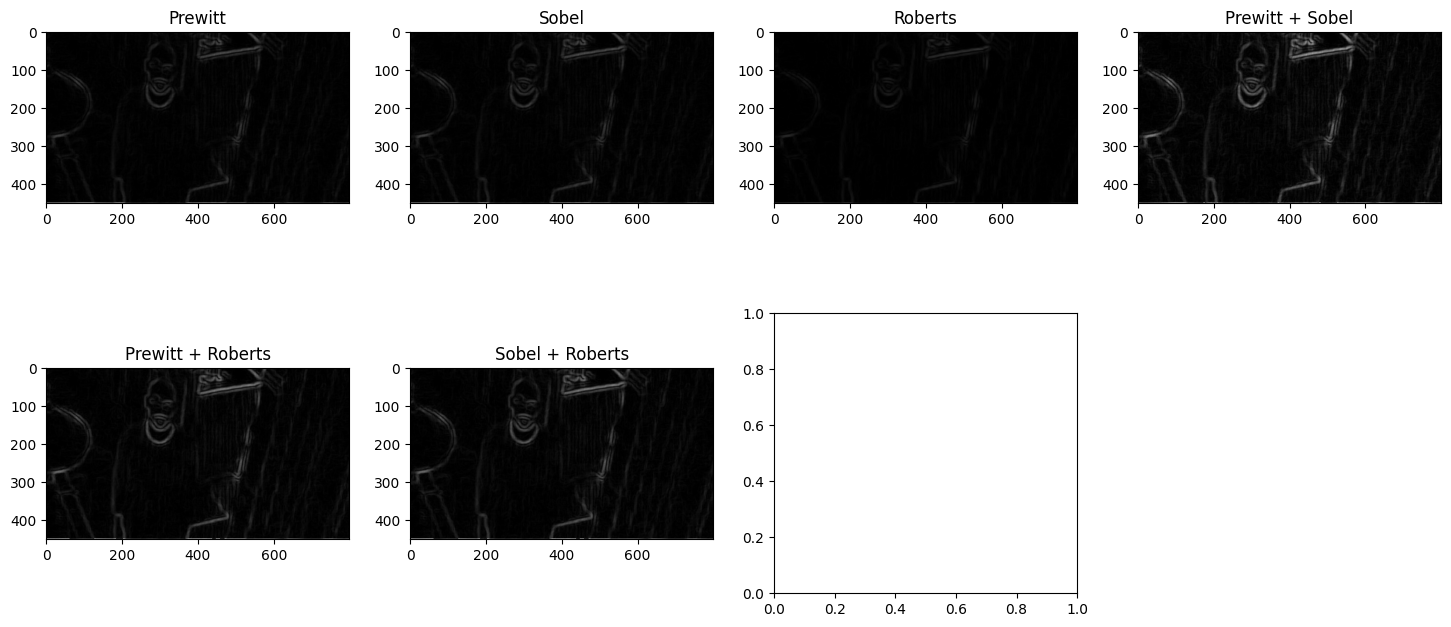

In [35]:
hasil_prewitt = edge(hasil_smoothing, prewittX, prewittY)
hasil_sobel   = edge(hasil_smoothing, sobelX, sobelY)
hasil_roberts = edge(hasil_smoothing, robertsX, robertsY)

PrewittSobel = edge (Smoothing_Sharpening, prewittX, prewittY)
PrewittSobel1 = edge (PrewittSobel, sobelX, sobelY)

PrewittRobert = edge (Smoothing_Sharpening, prewittX, prewittY)
PrewittRobert2 = edge (PrewittRobert, robertsX, robertsY)

SobelRobert = edge (Smoothing_Sharpening, sobelX, sobelY)
SobelRobert3 = edge (SobelRobert, robertsX, robertsY)

PrewittSobelRobert = edge (Smoothing_Sharpening, prewittX, prewittY)
PrewittSobelRobert1 = edge (PrewittSobelRobert, sobelX, sobelY)

plt.figure(figsize=(18,8))

plt.subplot(2,4,1)
plt.imshow(hasil_prewitt, cmap='gray')
plt.title('Prewitt')

plt.subplot(2,4,2)
plt.imshow(hasil_sobel, cmap='gray')
plt.title('Sobel')

plt.subplot(2,4,3)
plt.imshow(hasil_roberts, cmap='gray')
plt.title('Roberts')

plt.subplot(2,4,4)
plt.imshow(PrewittSobel, cmap='gray')
plt.title('Prewitt + Sobel')

plt.subplot(2,4,5)
plt.imshow(PrewittRobert, cmap='gray')
plt.title('Prewitt + Roberts')

plt.subplot(2,4,6)
plt.imshow(SobelRobert, cmap='gray')
plt.title('Sobel + Roberts')

plt.subplot(2,4,7)
plt.imshow(PrewittSobelRobert, cmap='gray')
plt.title('Prewitt + Sobel + Roberts')

plt.show()

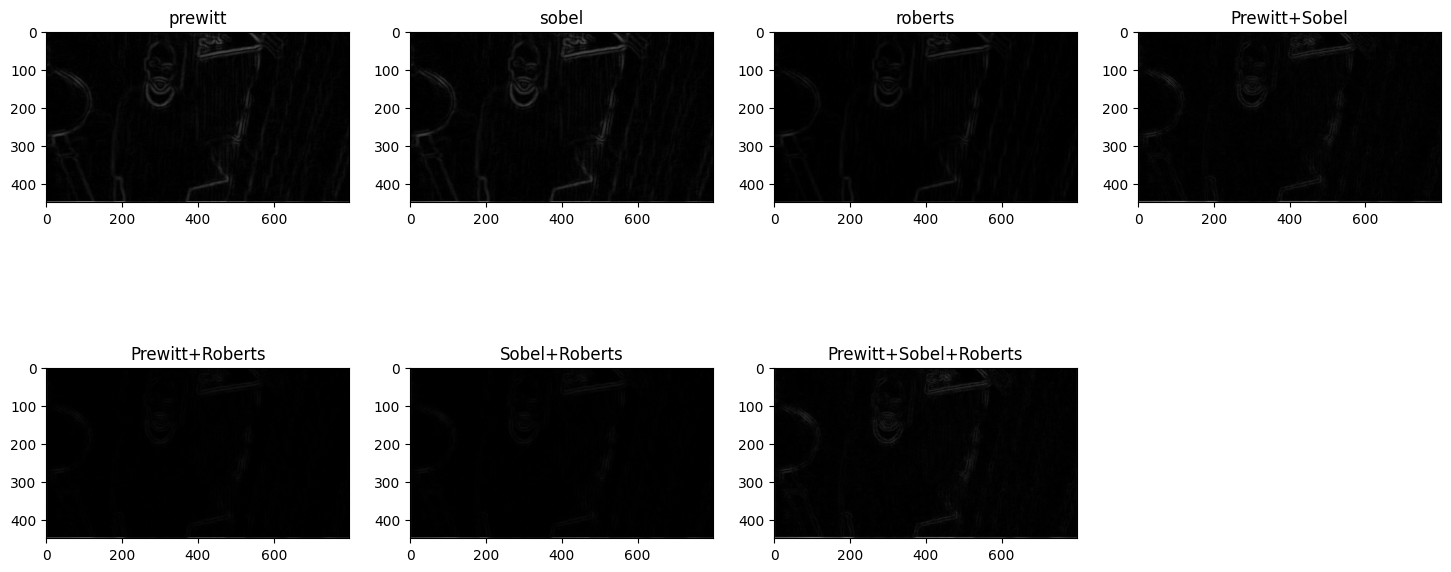

In [32]:
hasil_tepi_1 = edge(Smoothing_Sharpening, prewittX, prewittY)
hasil_tepi_2 = edge(Smoothing_Sharpening, sobelX, sobelY)
hasil_tepi_3= edge(Smoothing_Sharpening, robertsX, robertsY)

PrewittSobel = edge (Smoothing_Sharpening, prewittX, prewittY)
PrewittSobel1 = edge (PrewittSobel, sobelX, sobelY)

PrewittRobert = edge (Smoothing_Sharpening, prewittX, prewittY)
PrewittRobert2 = edge (PrewittRobert, robertsX, robertsY)

SobelRobert = edge (Smoothing_Sharpening, sobelX, sobelY)
SobelRobert3 = edge (SobelRobert, robertsX, robertsY)

PrewittSobelRobert = edge (Smoothing_Sharpening, prewittX, prewittY)
PrewittSobelRobert1 = edge (PrewittSobelRobert, sobelX, sobelY)

plt.figure(figsize=(18,8))

plt.subplot(2,4,1)
plt.imshow(hasil_tepi_1, cmap='gray')
plt.title('prewitt')

plt.subplot(2,4,2)
plt.imshow(hasil_tepi_2, cmap='gray')
plt.title('sobel')

plt.subplot(2,4,3)
plt.imshow(hasil_tepi_3, cmap='gray')
plt.title('roberts')

plt.subplot(2,4,4)
plt.imshow(PrewittSobel1, cmap='gray')
plt.title('Prewitt+Sobel')

plt.subplot(2,4,5)
plt.imshow(PrewittRobert2, cmap='gray')
plt.title('Prewitt+Roberts')

plt.subplot(2,4,6)
plt.imshow(SobelRobert3, cmap='gray')
plt.title('Sobel+Roberts')

plt.subplot(2,4,7)
plt.imshow(PrewittSobelRobert1, cmap='gray')
plt.title('Prewitt+Sobel+Roberts')

plt.show()